# Lead overlap plot development tutorial

This notebook demonstrates the in-development `gl.plot_lead_overlap()` API using sample data from `examples/0_sample_data`.

The function extracts lead variants from multiple loaded `Sumstats` objects, groups nearby leads into shared loci, annotates lead variants with nearby genes when `anno=True`, and plots the overlap.

- 2 or 3 studies: proportional Venn diagram via `matplotlib-venn`
- 4 or more studies, or `mode="upset"`: UpSet-style overlap plot

The overlap is based on coordinate windows around lead variants. It is not LD clumping.

In [1]:
import sys
sys.path.insert(0, "/home/yunye/work/gwaslab/src")
import gwaslab as gl

## Load sample `Sumstats` objects

Inputs:

- `../0_sample_data/t2d_bbj.txt.gz`
- `../0_sample_data/bmi_female_bbj.txt.gz`
- `../0_sample_data/bmi_male_bbj.txt.gz`

All three files use `SNP`, `CHR`, `POS`, `REF`, `ALT`, `BETA`, `SE`, and `P` columns.

In [2]:
load_kwargs = dict(
    snpid="SNP",
    chrom="CHR",
    pos="POS",
    ea="ALT",
    nea="REF",
    beta="BETA",
    se="SE",
    p="P",
    build="19",
    verbose=False,
)

t2d = gl.Sumstats("../0_sample_data/t2d_bbj.txt.gz", **load_kwargs)
t2d.meta["gwaslab"]["study_name"] = "T2D"

bmi_female = gl.Sumstats("../0_sample_data/bmi_female_bbj.txt.gz", **load_kwargs)
bmi_female.meta["gwaslab"]["study_name"] = "BMI female"

bmi_male = gl.Sumstats("../0_sample_data/bmi_male_bbj.txt.gz", **load_kwargs)
bmi_male.meta["gwaslab"]["study_name"] = "BMI male"

## Two-study Venn plot with gene annotation

Use `anno=True` to make `get_lead()` add `GENE` and `LOCATION` columns before overlap grouping. This may download or read the configured GTF reference if it is not already available.

2026/06/12 00:46:47 Start to plot lead overlap across sumstats objects...
2026/06/12 00:46:47 Configured plot style for plot_lead_overlap:None
2026/06/12 00:46:47  -Extracting lead variants for BMI female...
2026/06/12 00:46:47  -Genomic coordinates are based on GRCh37/hg19...
2026/06/12 00:46:47 Start to extract lead variants ...(v4.1.9)
2026/06/12 00:46:47  -Current Dataframe shape : 5961600 x 9 ; Memory usage: 335.44 MB
2026/06/12 00:46:47  -Processing 5961600 variants...
2026/06/12 00:46:47  -Significance threshold : 5e-08
2026/06/12 00:46:47  -Sliding window size: 500  kb
2026/06/12 00:46:48  -Using P for extracting lead variants...
2026/06/12 00:46:48  -Found 948 significant variants in total...
2026/06/12 00:46:48  -Identified 20 lead variants!
2026/06/12 00:46:48  -Annotating variants using references:ensembl
2026/06/12 00:46:48  -Annotating variants using references based on genome build:19
2026/06/12 00:46:48  -Genomic coordinates are based on GRCh37/hg19...
2026/06/12 00:46:

,LOCUS_ID,CHR,POS,STUDIES,N_STUDIES,GENE,LEAD_SNPS,MEMBERSHIP_KEY
0,Locus_1,1,155767708,BMI female,1,GON4L,"{'BMI female': 'rs860295', 'BMI male': ''}",1|0
1,Locus_2,1,177865756,"BMI female,BMI male",2,SEC16B,"{'BMI female': 'rs532504', 'BMI male': 'rs6337...",1|1
2,Locus_3,2,621558,"BMI female,BMI male",2,TMEM18,"{'BMI female': 'rs939584', 'BMI male': 'rs9395...",1|1
3,Locus_4,2,20433218,BMI male,1,SDC1,"{'BMI female': '', 'BMI male': 'rs111612372'}",0|1
4,Locus_5,2,25158008,BMI female,1,DNAJC27,"{'BMI female': 'rs713586', 'BMI male': ''}",1|0


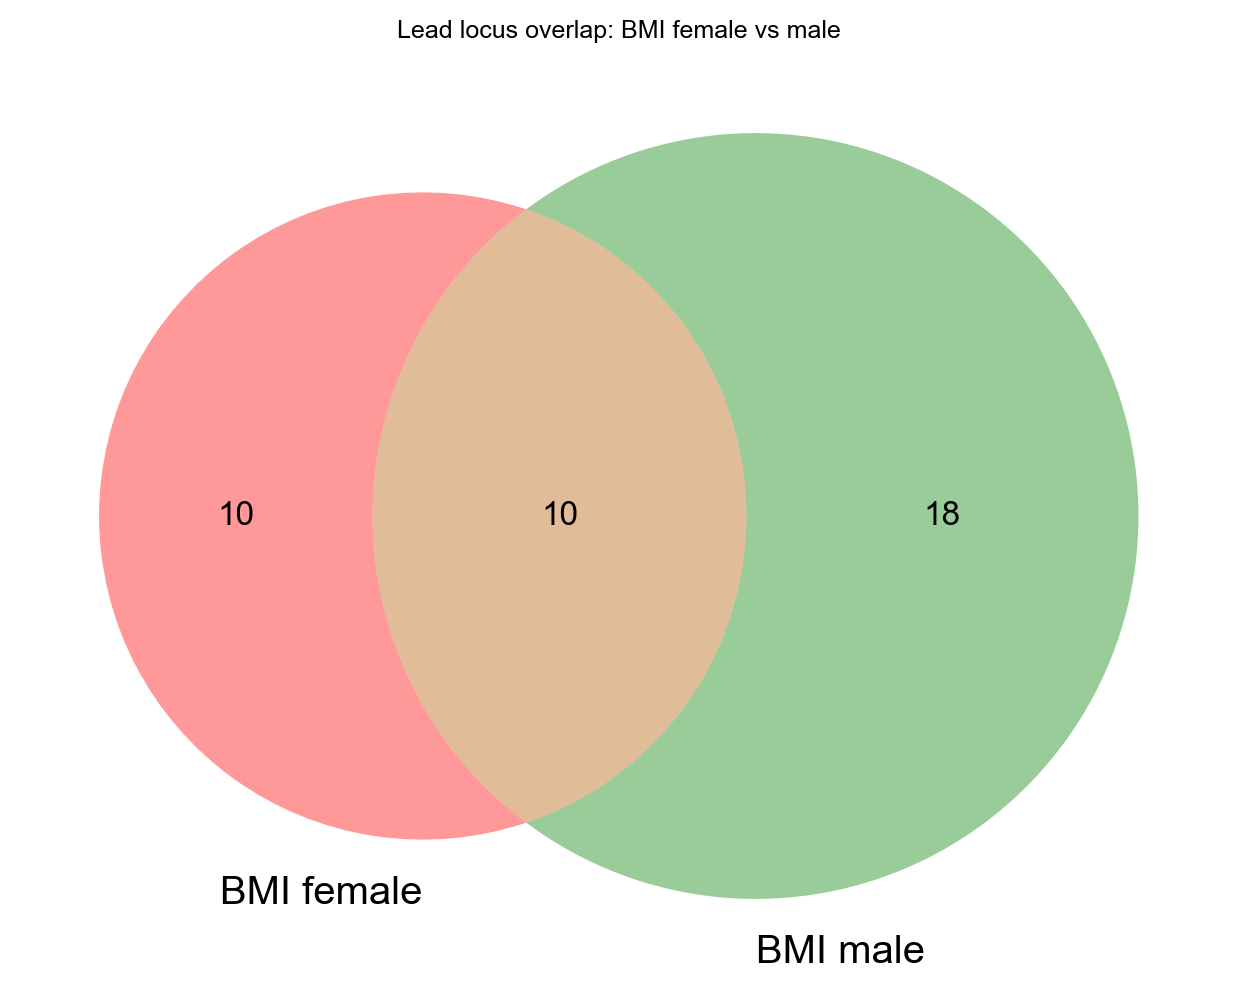

In [3]:
overlap_bmi, fig_bmi, log_bmi = gl.plot_lead_overlap(
    objects=[bmi_female, bmi_male],
    titles=["BMI female", "BMI male"],
    anno=True,
    build="19",
    source="ensembl",
    sig_level=5e-8,
    windowsizekb=500,
    windowsizekb_for_overlap=500,
    title="Lead locus overlap: BMI female vs male",
    verbose=True,
)

overlap_bmi[["LOCUS_ID", "CHR", "POS", "STUDIES", "N_STUDIES", "GENE", "LEAD_SNPS", "MEMBERSHIP_KEY"]].head()

## Three-study Venn plot

Use all requested sample traits: T2D, BMI female, and BMI male.

2026/06/12 00:47:07 Start to plot lead overlap across sumstats objects...
2026/06/12 00:47:07 Configured plot style for plot_lead_overlap:None
2026/06/12 00:47:07  -Extracting lead variants for T2D...
2026/06/12 00:47:07  -Genomic coordinates are based on GRCh37/hg19...
2026/06/12 00:47:07 Start to extract lead variants ...(v4.1.9)
2026/06/12 00:47:07  -Current Dataframe shape : 12557761 x 9 ; Memory usage: 745.61 MB
2026/06/12 00:47:07 #WARNING! Data types were not fixed for : CHR 
2026/06/12 00:47:07 Start to fix chromosome notation (CHR) ...(v4.1.9)
2026/06/12 00:47:07  -Checking CHR data type...
2026/06/12 00:47:08  -Variants with standardized chromosome notation: 12228970
2026/06/12 00:47:09  -Variants with fixable chromosome notations: 328791
2026/06/12 00:47:09  -No unrecognized chromosome notations...
2026/06/12 00:47:09  -Identifying non-autosomal chromosomes : X, Y, and MT ...
2026/06/12 00:47:09  -Identified 328791 variants on sex chromosomes...
2026/06/12 00:47:09  -Standar

,LOCUS_ID,CHR,POS,STUDIES,N_STUDIES,GENE,LEAD_SNPS,MEMBERSHIP_KEY
0,Locus_1,1,22068326,T2D,1,USP48,"{'T2D': '1:22068326_A_G', 'BMI female': '', 'B...",1|0|0
1,Locus_2,1,51103268,T2D,1,FAF1,"{'T2D': '1:51103268_T_C', 'BMI female': '', 'B...",1|0|0
2,Locus_3,1,154309595,T2D,1,ATP8B2,"{'T2D': '1:154309595_TA_T', 'BMI female': '', ...",1|0|0
3,Locus_4,1,155767708,BMI female,1,GON4L,"{'T2D': '', 'BMI female': 'rs860295', 'BMI mal...",0|1|0
4,Locus_5,1,177865756,"BMI female,BMI male",2,SEC16B,"{'T2D': '', 'BMI female': 'rs532504', 'BMI mal...",0|1|1


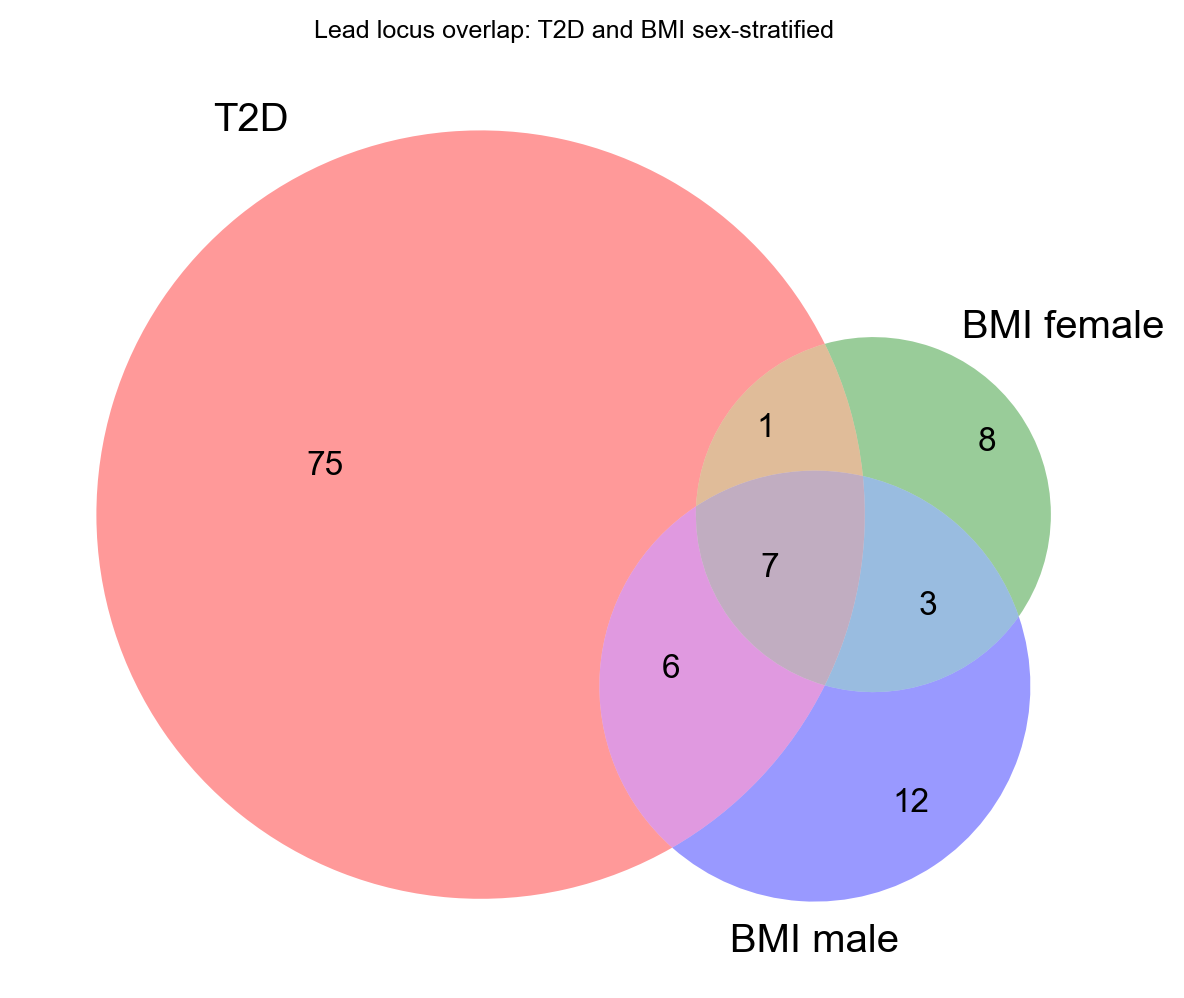

In [4]:
overlap_three, fig_three, log_three = gl.plot_lead_overlap(
    objects=[t2d, bmi_female, bmi_male],
    titles=["T2D", "BMI female", "BMI male"],
    anno=True,
    build="19",
    source="ensembl",
    sig_level=5e-8,
    windowsizekb=500,
    windowsizekb_for_overlap=1000,
    title="Lead locus overlap: T2D and BMI sex-stratified",
    verbose=True,
)

overlap_three[["LOCUS_ID", "CHR", "POS", "STUDIES", "N_STUDIES", "GENE", "LEAD_SNPS", "MEMBERSHIP_KEY"]].head()

## UpSet-style layout

Force the UpSet-style layout with `mode="upset"`. This is useful while developing the layout and is the automatic choice for four or more studies.

2026/06/12 00:47:44 Start to plot lead overlap across sumstats objects...
2026/06/12 00:47:44 Configured plot style for plot_lead_overlap:None
2026/06/12 00:47:44  -Extracting lead variants for T2D...
2026/06/12 00:47:44  -Genomic coordinates are based on GRCh37/hg19...
2026/06/12 00:47:44 Start to extract lead variants ...(v4.1.9)
2026/06/12 00:47:44  -Processing 12557761 variants...
2026/06/12 00:47:44  -Significance threshold : 5e-08
2026/06/12 00:47:44  -Sliding window size: 500  kb
2026/06/12 00:47:46  -Using P for extracting lead variants...
2026/06/12 00:47:46  -Found 9461 significant variants in total...
2026/06/12 00:47:46  -Identified 89 lead variants!
2026/06/12 00:47:46  -Annotating variants using references:ensembl
2026/06/12 00:47:46  -Annotating variants using references based on genome build:19
2026/06/12 00:47:46  -Genomic coordinates are based on GRCh37/hg19...
2026/06/12 00:47:46 Start to annotate variants with nearest gene name(s) ...(v4.1.9)
2026/06/12 00:47:46  -G

,SET_ID,LOCUS_ID,CHR,POS,STUDIES,N_STUDIES,GENE,LEAD_SNPS,MEMBERSHIP_KEY
0,Set1,Locus_1,1,22068326,T2D,1,USP48,"{'T2D': '1:22068326_A_G', 'BMI female': '', 'B...",1|0|0
1,Set1,Locus_2,1,51103268,T2D,1,FAF1,"{'T2D': '1:51103268_T_C', 'BMI female': '', 'B...",1|0|0
2,Set1,Locus_3,1,154309595,T2D,1,ATP8B2,"{'T2D': '1:154309595_TA_T', 'BMI female': '', ...",1|0|0
3,Set3,Locus_4,1,155767708,BMI female,1,GON4L,"{'T2D': '', 'BMI female': 'rs860295', 'BMI mal...",0|1|0
4,Set6,Locus_5,1,177865756,"BMI female,BMI male",2,SEC16B,"{'T2D': '', 'BMI female': 'rs532504', 'BMI mal...",0|1|1


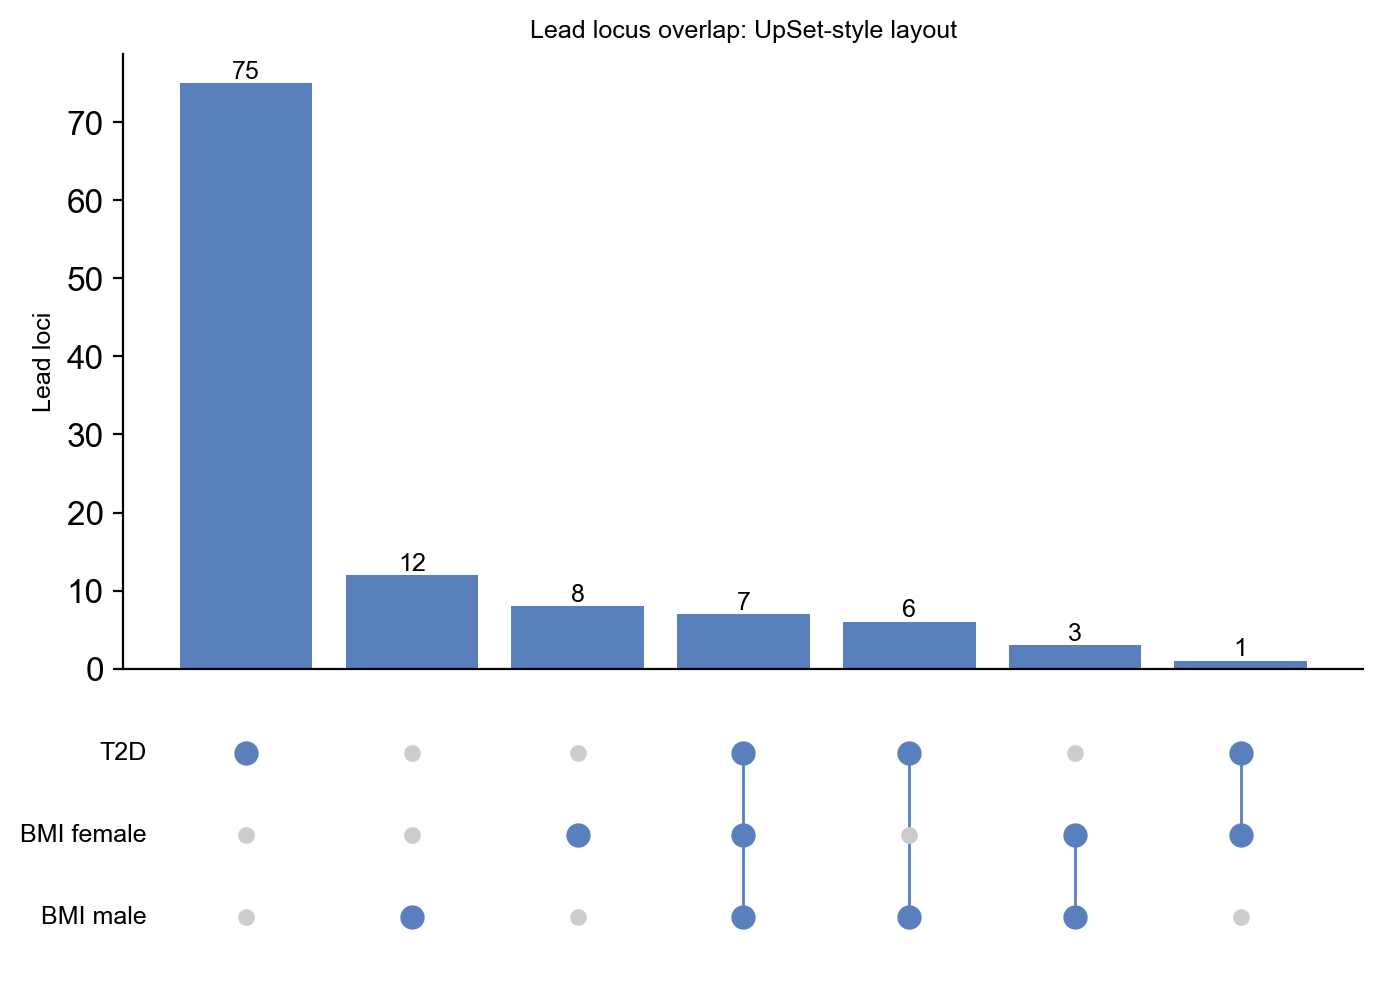

In [5]:
overlap_upset, fig_upset, log_upset = gl.plot_lead_overlap(
    objects=[t2d, bmi_female, bmi_male],
    titles=["T2D", "BMI female", "BMI male"],
    anno=True,
    build="19",
    source="ensembl",
    sig_level=5e-8,
    windowsizekb=500,
    windowsizekb_for_overlap=1000,
    mode="upset",
    title="Lead locus overlap: UpSet-style layout",
    verbose=True,
)

overlap_upset.attrs["set_list"]

# Per-locus table includes the compact SET_ID used on the x-axis.
overlap_upset[["SET_ID", "LOCUS_ID", "CHR", "POS", "STUDIES", "N_STUDIES", "GENE", "LEAD_SNPS", "MEMBERSHIP_KEY"]].head()